In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, train_test_split, learning_curve
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeRegressor
from statsmodels.tsa.stattools import adfuller



In [2]:
df = pd.read_csv(r'd:\PROJECTS\celebal ds\tesla_deliveries_dataset_2015_2025.csv')
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
print(df.shape)
print(df.columns.tolist())
df.info()

(2640, 12)
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640

In [4]:
print(df.isnull().sum())
df = df.ffill()
df.drop_duplicates(inplace=True)
print("Final Shape:", df.shape)

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64
Final Shape: (2640, 12)


In [5]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


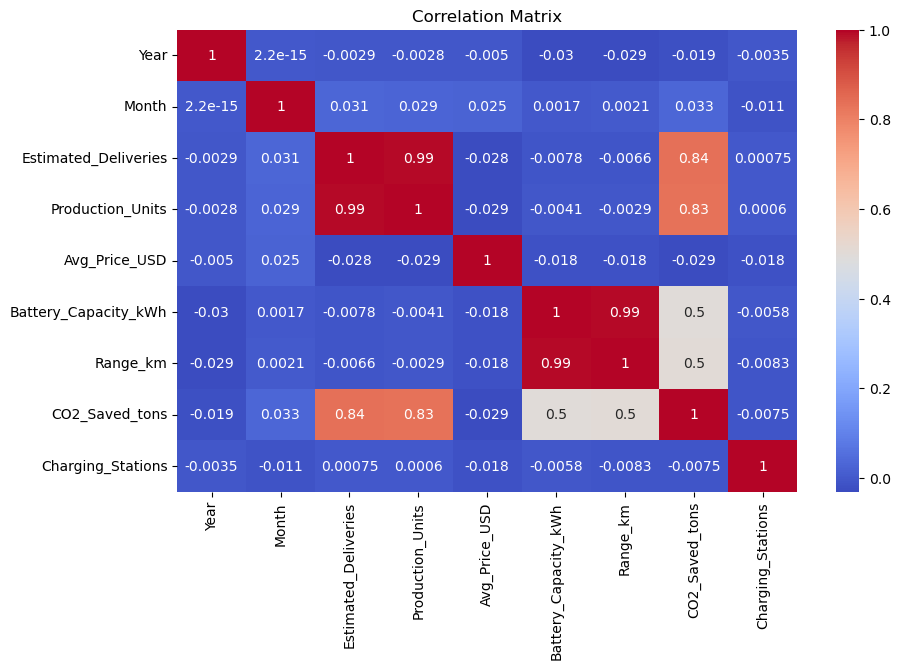

In [6]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

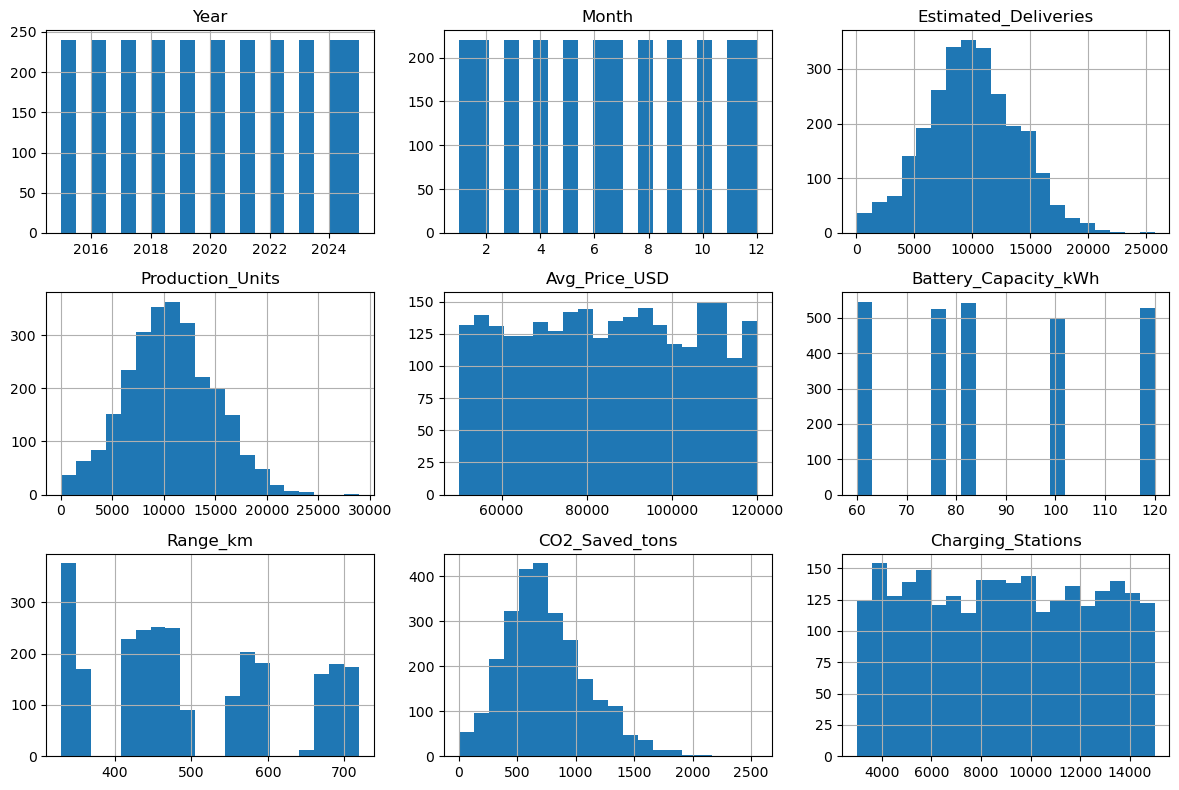

In [7]:
df.hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

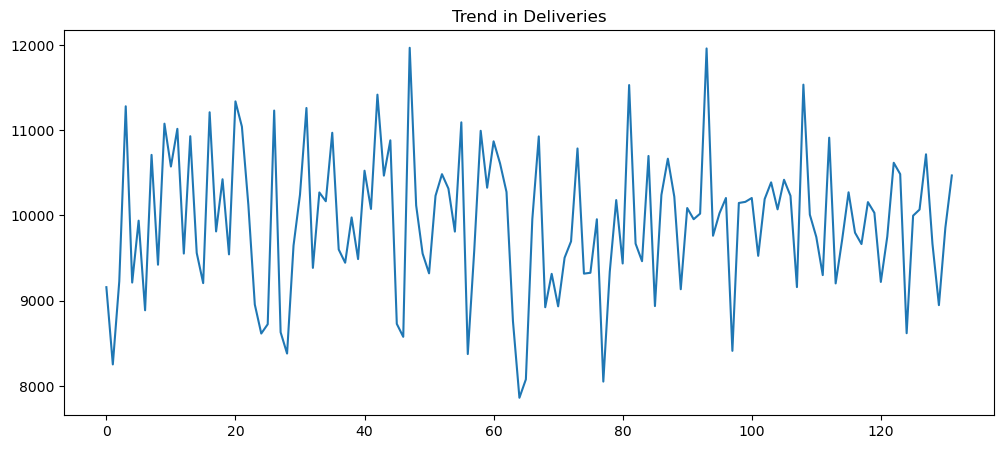

In [8]:
monthly = df.groupby(['Year','Month'])['Estimated_Deliveries'].mean().reset_index()
plt.figure(figsize=(12,5))
plt.plot(monthly['Estimated_Deliveries'])
plt.title('Trend in Deliveries')
plt.show()

In [9]:
for col in ['Region','Model','Source_Type']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722


In [10]:
df['Quarter'] = ((df['Month']-1)//3)+1
df['Delivery_Ratio'] = df['Estimated_Deliveries'] / df['Production_Units']
df['Price_Per_KM'] = df['Avg_Price_USD'] / df['Range_km']

In [11]:
df['Lag_1'] = df['Estimated_Deliveries'].shift(1)
df['Lag_2'] = df['Estimated_Deliveries'].shift(2)

In [12]:
df['Rolling_Mean_3'] = df['Estimated_Deliveries'].rolling(3).mean()
df['Rolling_STD_3'] = df['Estimated_Deliveries'].rolling(3).std()
df.dropna(inplace=True)

In [13]:
result = adfuller(df['Estimated_Deliveries'])
print("ADF Statistic:", result[0])
print("P-value:", result[1])
if result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is Non-Stationary")

ADF Statistic: -53.7239966933782
P-value: 0.0
Series is Stationary


In [14]:
X = df.drop('Estimated_Deliveries', axis=1)
y = df['Estimated_Deliveries']
selector = SelectKBest(score_func=f_regression, k=8)
selector.fit(X,y)
selected_features = X.columns[selector.get_support()]
print(selected_features)

Index(['Month', 'Production_Units', 'Avg_Price_USD', 'CO2_Saved_tons',
       'Quarter', 'Lag_1', 'Rolling_Mean_3', 'Rolling_STD_3'],
      dtype='object')


In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("Explained Variance Ratio")
print(pca.explained_variance_ratio_)

Explained Variance Ratio
[0.17288957 0.12061028]


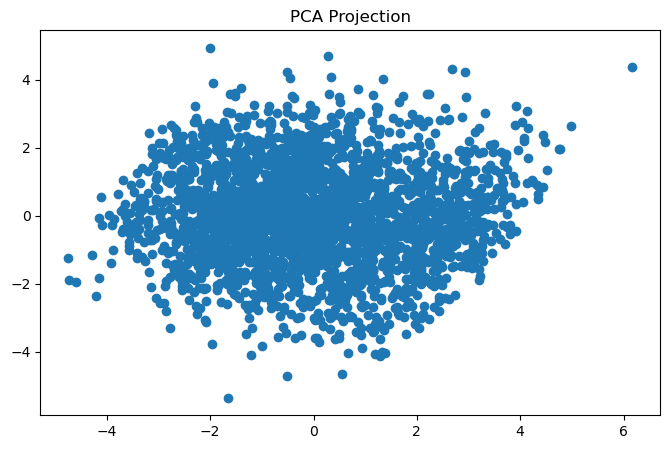

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA Projection")
plt.show()

In [18]:
df = df.sort_values(['Year','Month'])
split = int(len(df)*0.8)
train = df[:split]
test = df[split:]
X_train = train.drop('Estimated_Deliveries', axis=1)
y_train = train['Estimated_Deliveries']
X_test = test.drop('Estimated_Deliveries', axis=1)
y_test = test['Estimated_Deliveries']

In [19]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
pipeline.fit(X_train,y_train)
y_pred = pipeline.predict(X_test)

In [20]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 6.7729794836574886e-12
MSE: 7.115946549883262e-23
RMSE: 8.43560700239364e-12
R2: 1.0


In [21]:
print("Train R2:", pipeline.score(X_train,y_train))
print("Test R2:", pipeline.score(X_test,y_test))

Train R2: 1.0
Test R2: 1.0


In [22]:
ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])
ridge.fit(X_train,y_train)
ridge_pred = ridge.predict(X_test)
print("Ridge R2:", r2_score(y_test,ridge_pred))

Ridge R2: 0.9995228296120969


In [23]:
lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso())
])
lasso.fit(X_train,y_train)
lasso_pred = lasso.predict(X_test)
print("Lasso R2:", r2_score(y_test,lasso_pred))

Lasso R2: 0.9990188306284645


c:\Users\vinit\anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.610e+06, tolerance: 3.368e+06
  model = cd_fast.enet_coordinate_descent(


In [24]:
tscv = TimeSeriesSplit(n_splits=5)
for train_idx, test_idx in tscv.split(X):
    print("Train:", len(train_idx), "Test:", len(test_idx))

Train: 443 Test: 439
Train: 882 Test: 439
Train: 1321 Test: 439
Train: 1760 Test: 439
Train: 2199 Test: 439


In [25]:
params = {'model__alpha':[0.01,0.1,1,10,100]}
grid = GridSearchCV(
    ridge,
    params,
    cv=5,
    scoring='r2'
)
grid.fit(X_train,y_train)
print("Best Parameters:", grid.best_params_)

Best Parameters: {'model__alpha': 0.01}


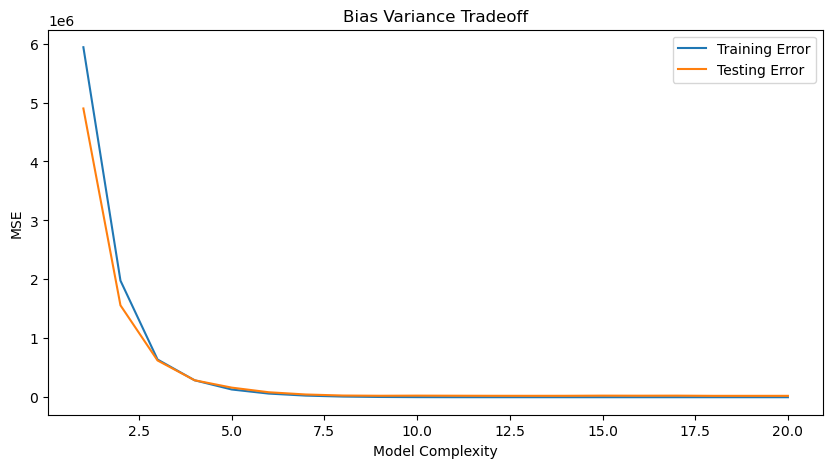

In [26]:
depths = range(1,21)
train_errors = []
test_errors = []
for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train,y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_errors.append(mean_squared_error(y_train,train_pred))
    test_errors.append(mean_squared_error(y_test,test_pred))
plt.figure(figsize=(10,5))
plt.plot(depths,train_errors,label='Training Error')
plt.plot(depths,test_errors,label='Testing Error')
plt.legend()
plt.title('Bias Variance Tradeoff')
plt.xlabel('Model Complexity')
plt.ylabel('MSE')
plt.show()

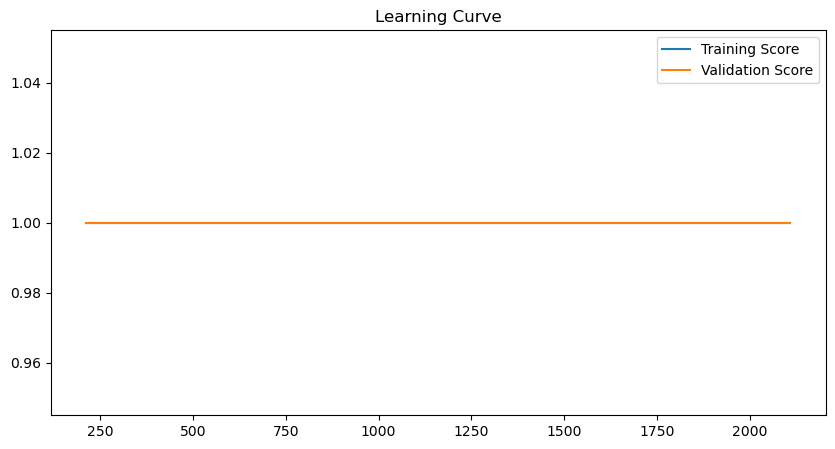

In [27]:
train_sizes, train_scores, val_scores = learning_curve(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring='r2'
)
plt.figure(figsize=(10,5))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training Score')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation Score')
plt.legend()
plt.title('Learning Curve')
plt.show()

In [28]:
print('Scaling is applied through Pipeline after splitting data.')
print('Chronological split prevents future information leakage.')

Scaling is applied through Pipeline after splitting data.
Chronological split prevents future information leakage.


In [29]:
best_model = grid.best_estimator_
future = X.iloc[[-1]]
forecast = best_model.predict(future)
print("Forecasted Deliveries:", forecast[0])

Forecasted Deliveries: 2636.09886994689


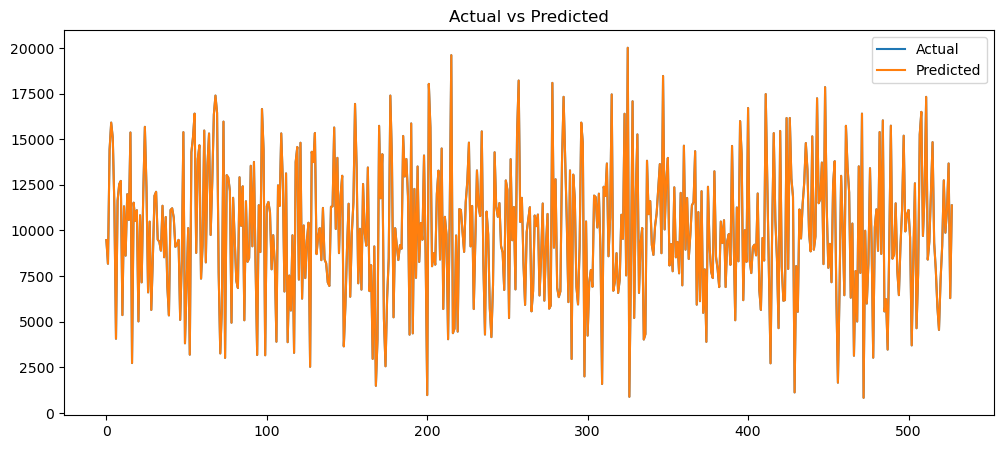

In [30]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values,label='Actual')
plt.plot(y_pred,label='Predicted')
plt.legend()
plt.title('Actual vs Predicted')
plt.show()

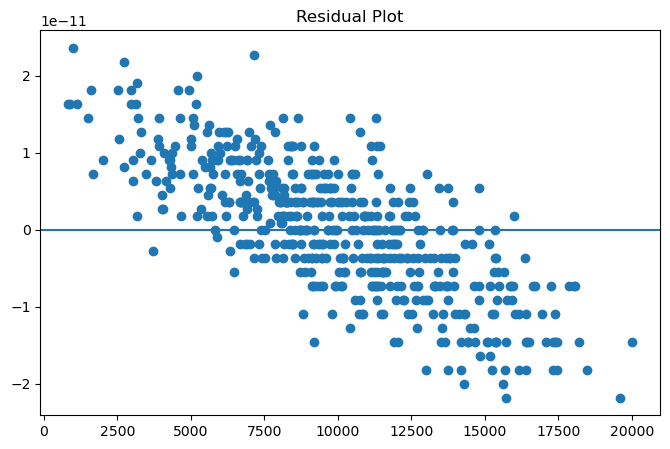

In [31]:
residuals = y_test - y_pred
plt.figure(figsize=(8,5))
plt.scatter(y_pred,residuals)
plt.axhline(0)
plt.title('Residual Plot')
plt.show()